In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

category_stats = apps.groupby('Category').agg(
    avg_rating=('Rating', 'mean'),
    total_installs=('Installs', 'sum'),
    app_count=('App', 'count'),
    avg_price=('Price', 'mean')
).sort_values('avg_rating', ascending=False)

print(category_stats.head(10))
print(category_stats.tail(10))

                     avg_rating  total_installs  app_count  avg_price
Category                                                             
EVENTS                 4.435556        15973161         64   1.718594
EDUCATION              4.364407       352952000        119   0.150924
ART_AND_DESIGN         4.357377       114338100         64   0.093281
BOOKS_AND_REFERENCE    4.344970      1665969576        222   0.539505
PERSONALIZATION        4.332215      1532494782        376   0.400213
PARENTING              4.300000        31521110         60   0.159667
BEAUTY                 4.278571        27197050         53   0.000000
GAME                   4.247368     13878924415        959   0.296465
SOCIAL                 4.247291      5487867902        239   0.066820
WEATHER                4.243056       361100520         79   0.410380
                     avg_rating  total_installs  app_count  avg_price
Category                                                             
NEWS_AND_MAGAZINES  

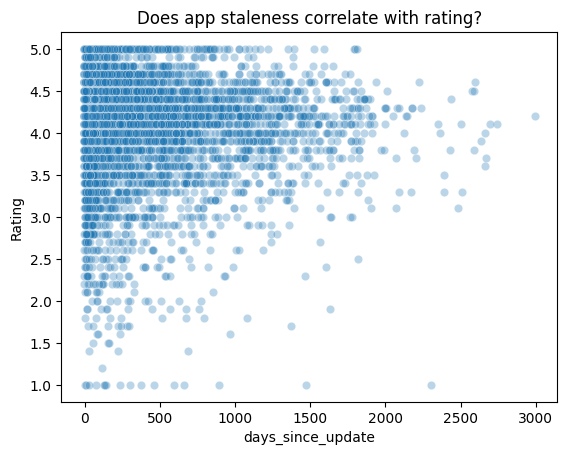

In [ ]:
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'])
apps['days_since_update'] = (pd.Timestamp('2018-08-01') - apps['Last Updated']).dt.days

sns.scatterplot(data=apps, x='days_since_update', y='Rating', alpha=0.3)
plt.title('Does app staleness correlate with rating?')
plt.show()

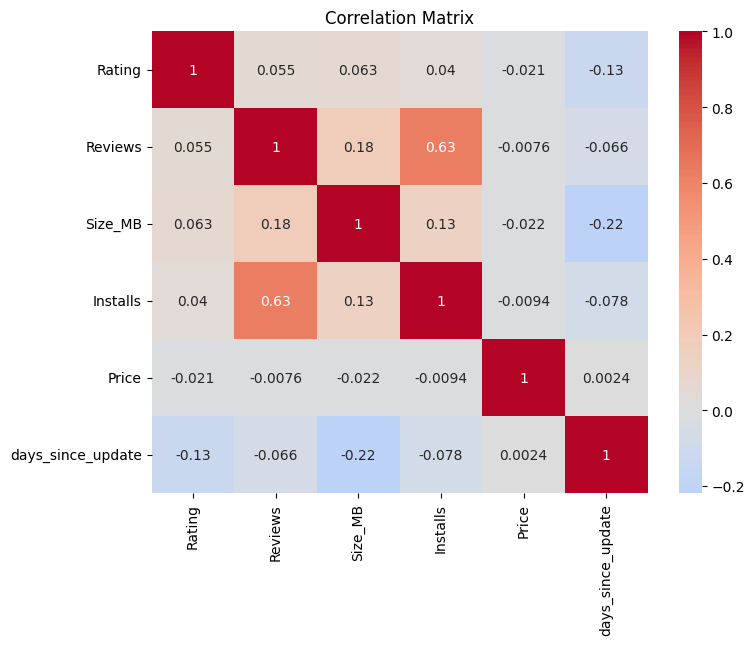

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Size_MB', 'Installs', 'Price', 'days_since_update']
corr = apps[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

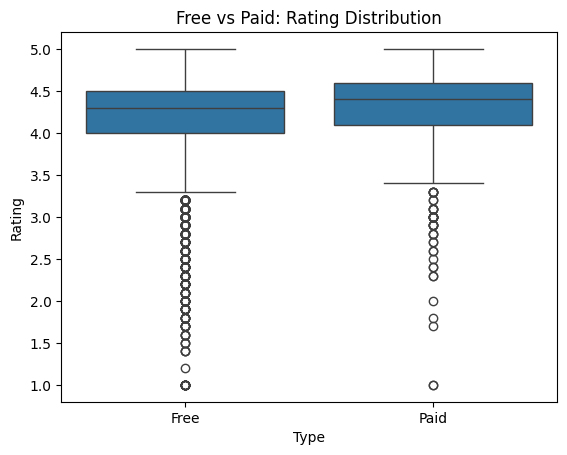

In [ ]:
sns.boxplot(data=apps, x='Type', y='Rating')
plt.title('Free vs Paid: Rating Distribution')
plt.show()

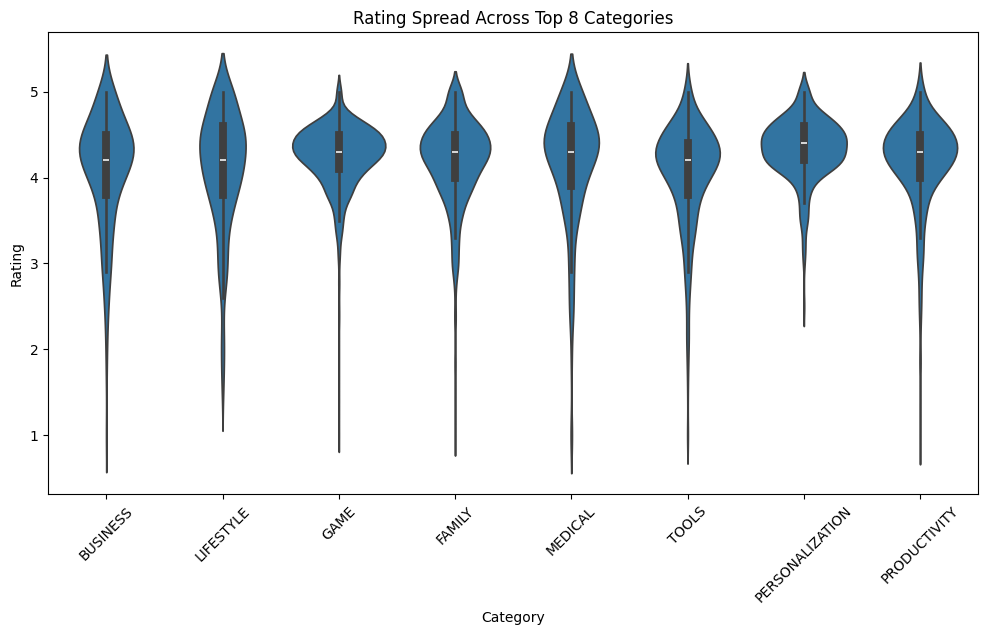

In [ ]:
top_categories = apps['Category'].value_counts().head(8).index
subset = apps[apps['Category'].isin(top_categories)]

plt.figure(figsize=(12,6))
sns.violinplot(data=subset, x='Category', y='Rating')
plt.xticks(rotation=45)
plt.title('Rating Spread Across Top 8 Categories')
plt.show()

In [ ]:
merged = reviews_clean.merge(apps[['App', 'Category']], on='App', how='inner')
sentiment_by_category = merged.groupby('Category')['Sentiment'].value_counts(normalize=True).unstack()
print(sentiment_by_category.sort_values('Negative', ascending=False).head(10))

Sentiment           Negative   Neutral  Positive
Category                                        
GAME                0.360587  0.050015  0.589398
SOCIAL              0.282051  0.172740  0.545209
FAMILY              0.274764  0.103534  0.621702
NEWS_AND_MAGAZINES  0.265385  0.139423  0.595192
ENTERTAINMENT       0.252373  0.146361  0.601266
VIDEO_PLAYERS       0.250755  0.175227  0.574018
SPORTS              0.227857  0.137931  0.634212
FINANCE             0.222997  0.142160  0.634843
TRAVEL_AND_LOCAL    0.216903  0.171986  0.611111
DATING              0.210496  0.166764  0.622741


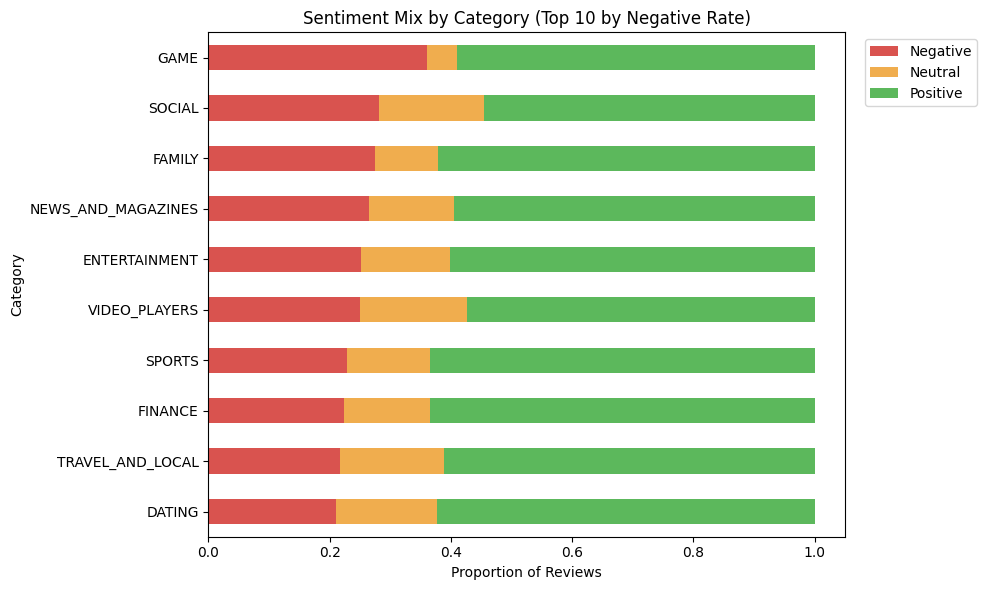

In [ ]:
sentiment_by_category.sort_values('Negative', ascending=False).head(10)[['Negative','Neutral','Positive']].plot(
    kind='barh', stacked=True, figsize=(10,6), color=['#d9534f','#f0ad4e','#5cb85c']
)
plt.xlabel('Proportion of Reviews')
plt.title('Sentiment Mix by Category (Top 10 by Negative Rate)')
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()